In [1]:
import pandas as pd

In [2]:
data = pd.read_csv('https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv')

In [101]:
df = data.copy()

In [102]:
df.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


In [103]:
idx = [
    'engine_displacement',
    'horsepower',
    'vehicle_weight',
    'model_year',
    'fuel_efficiency_mpg'
]
df = df[idx]

In [104]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

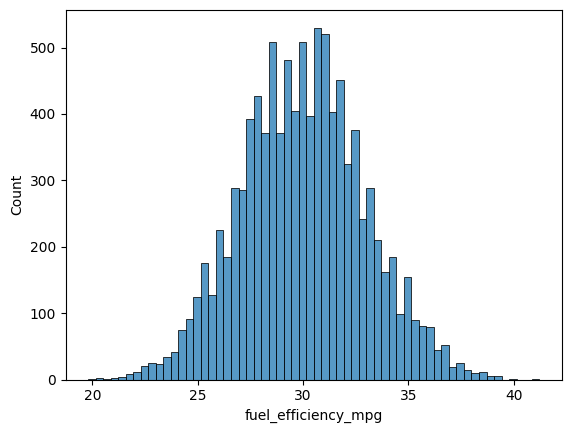

In [105]:
sns.histplot(df.fuel_efficiency_mpg)

In [106]:
df.isnull().sum()

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

In [107]:
df['horsepower'].median()

np.float64(254.0)

In [108]:
import numpy as np

n = len(df)
n_train = int(n * 0.6)
n_val = int(n * 0.2)
n_test = n - (n_train + n_val)

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train+n_val]]
df_test = df.iloc[idx[n_train+n_val:]]

In [109]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [110]:
y_train = df_train.fuel_efficiency_mpg.values
y_val = df_val.fuel_efficiency_mpg.values
y_test = df_test.fuel_efficiency_mpg.values

In [111]:
y_train

array([32.5, 29.1, 34.1, ..., 27.7, 31.6, 28. ])

In [112]:
del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

In [113]:
#dot function

def dot(xi,w):
    n = len(xi)
    res = 0

    for i in range(n):
        res = res + xi[i]*w[i]

    return res

In [114]:
#train a linear regression model

def train_linear_regression(xi,y):
    ones = np.ones(xi.shape[0])
    xi = np.column_stack([ones,xi])
    
    XTX = xi.T.dot(xi)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(xi.T).dot(y)
    
    return w_full

In [115]:
#linear regression

def linear_regression(xi):
    return w_0 + xi.dot(w)

In [144]:
#RMSE

def rmse(xi,y):
    return np.sqrt(((xi-y)**2).mean())

In [145]:
#fill it with 0

base = [
    'engine_displacement',
    'horsepower',
    'vehicle_weight',
    'model_year'
]

X_train = df_train[base].fillna(0).values
X_val = df_val[base].fillna(0).values

In [146]:
w_full = train_linear_regression(X_train,y_train)

w_0 = w_full[0]
w = w_full[1:]

RMSE = rmse(linear_regression(X_val),y_val)
print(RMSE.round(3))

2.206


In [147]:
#fill it with mean

base = [
    'engine_displacement',
    'horsepower',
    'vehicle_weight',
    'model_year'
]

num_train = df_train.mean()
num_val = df_val.mean()

X_train = df_train[base].fillna(num_train).values
X_val = df_val[base].fillna(num_val).values

In [148]:
w_full = train_linear_regression(X_train,y_train)

w_0 = w_full[0]
w = w_full[1:]

RMSE = rmse(linear_regression(X_val),y_val)
print(RMSE.round(3))

2.203


In [149]:
#regularized linear regression

base = [
    'engine_displacement',
    'horsepower',
    'vehicle_weight',
    'model_year'
]

X_train = df_train[base].fillna(0).values
X_val = df_val[base].fillna(0).values

In [150]:
r = [0, 0.01, 0.1, 1, 5, 10, 100]
ones = np.ones(X_train.shape[0])
X_train = np.column_stack([ones,X_train])

XTX_train = X_train.T.dot(X_train)

In [151]:
for i in range(len(r)):
    XTX_reg = XTX_train + r[i] * np.eye(len(XTX_train))
    XTX_reg_inv = np.linalg.inv(XTX_reg)
    w_full = XTX_reg_inv.dot(X_train.T).dot(y_train)
    w_0 = w_full[0]
    w = w_full[1:]
    RMSE = rmse(linear_regression(X_val),y_val)
    print(RMSE.round(4))

2.2057
2.2055
2.2138
2.3192
2.3879
2.4005
2.4129


In [152]:
#change random seed

seeds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
scores = []

for i in range(len(seeds)):
    np.random.seed(seeds[i])
    idx = np.arange(n)
    np.random.shuffle(idx)
    
    df_train = df.iloc[idx[:n_train]]
    df_val = df.iloc[idx[n_train:n_train+n_val]]
    df_test = df.iloc[idx[n_train+n_val:]]
    
    df_train = df_train.reset_index(drop=True)
    df_val = df_val.reset_index(drop=True)
    df_test = df_test.reset_index(drop=True)
    
    y_train = df_train.fuel_efficiency_mpg.values
    y_val = df_val.fuel_efficiency_mpg.values
    y_test = df_test.fuel_efficiency_mpg.values
    
    del df_train['fuel_efficiency_mpg']
    del df_val['fuel_efficiency_mpg']
    del df_test['fuel_efficiency_mpg']
    
    base = [
        'engine_displacement',
        'horsepower',
        'vehicle_weight',
        'model_year'
    ]
    
    X_train = df_train[base].fillna(0).values
    X_val = df_val[base].fillna(0).values
    
    w_full = train_linear_regression(X_train,y_train)
    
    w_0 = w_full[0]
    w = w_full[1:]
    
    score = rmse(linear_regression(X_val),y_val)
    scores.append(score)

In [153]:
np.std(scores).round(3)

np.float64(0.029)

In [154]:
#Evaluation

np.random.seed(9)
idx = np.arange(n)
np.random.shuffle(idx)
    
df_train = df.iloc[idx[:n_train+n_val]]
df_test = df.iloc[idx[n_train+n_val:]]
    
df_train = df_train.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)
    
y_train = df_train.fuel_efficiency_mpg.values
y_test = df_test.fuel_efficiency_mpg.values
    
del df_train['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']
    
base = [
    'engine_displacement',
    'horsepower',
    'vehicle_weight',
    'model_year'
    ]
    
X_train = df_train[base].fillna(0).values
X_test = df_test[base].fillna(0).values

ones = np.ones(X_train.shape[0])
X_train = np.column_stack([ones,X_train])

In [155]:
XTX_train = X_train.T.dot(X_train)
XTX_train = XTX_train+ 0.001 * np.eye(len(XTX_train))
XTX_train_inv = np.linalg.inv(XTX_train)
w_full = XTX_train_inv.dot(X_train.T).dot(y_train)
w_0 = w_full[0]
w = w_full[1:]
RMSE = rmse(linear_regression(X_test),y_test)
print(RMSE)

2.235827747194592
